## 前言
https://codetop.cc/home

力扣hot100 高频考查题 

---


### 常用的数据结构
- 链表
- 二叉树

In [59]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

### 121. 买卖股票的最佳时机
解题思路1：单调递增栈：利润产生在每次出售的时候, 这个出售的时刻就是股票要下跌了，代码里就是price < stack[-1], 还有处理一下最后一个价格  
解题思路2：动态规划：初始状态，历史最低值为无穷大，利润为,0；状态转移方程是dp[i] = max(dp[i-1], prices[i] - low)  
动态规划看上去比单调栈简洁

---
调递增栈 ≠ 最大栈。  
单调栈：是为了处理 下一个更大/更小元素 这种问题的技巧（常见于“接雨水”“每日温度”等）。  
最大栈/最小栈：是为了在栈中 快速查询当前最大值/最小值 的数据结构。  

In [1]:
a = [5,2,4]
a.pop()

4

In [9]:
# 解题思路2：动态规划：初始状态，历史最低值为无穷大，利润为,0；状态转移方程是dp[i] = max(dp[i-1], prices[i] - low)
def maxProfit(prices):
    # 初始状态, 历史最低价和卖出的最大收益
    dp = [(float('inf'),0)]*(len(prices)+1)
    for i,price in enumerate(prices):
        low,max_profit = dp[i]
        low = min(low,price)
        max_profit = max(max_profit, price-low)
        # 状态转移方程
        dp[i+1] = (low, max_profit)
    print(dp)
    
# 优化空间版本
def maxProfit(prices):
    # 初始状态, 历史最低价和卖出的最大收益
    low,max_profit = (float('inf'),0)
    for i,price in enumerate(prices): 

        # 状态转移方程
        low = min(low,price)
        max_profit = max(max_profit, price-low)
        # print(low,max_profit)
    return max_profit



prices = [7,1,5,3,6,4]
maxProfit(prices)






5

### 53. 最大子数组和
利用动态规划 做出一个时间复杂度O(N)空间复杂度O(1) ,或者使用分治做出一个更优的O(logN)  
#### DP(序列模版 40%) 
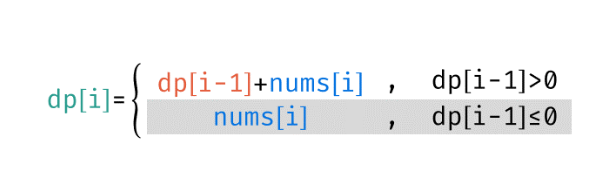    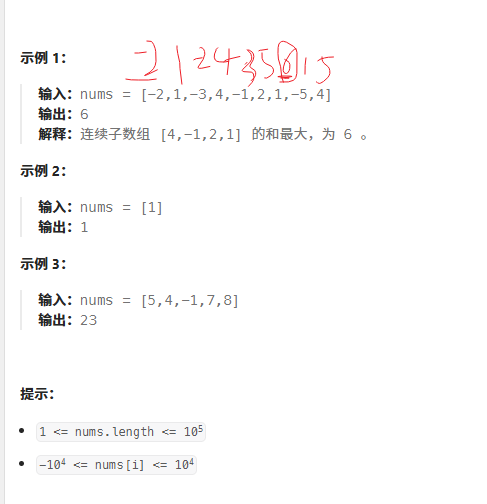

根据上面的状态转移方程
dp[0] = Sequence[0]
状态1对应的解，要么从自己开始，要么继续前面的解
- 从自己开始：前面的解已经小于0了，最大和的连续子数组要重新开始了，只有当前
- 继续前面的解：最大和的连续子数组还可以的叠加，所以当前解是前面+当前

这样分析之后，dp表的初始化也有可解释行了，因为前面没解，就当做是float('-inf')  
所以序列问题也可以申请dp表空间的时候比原序列长一点，但是做了空间优化的dp,空间复杂度是O(1)  

In [8]:
def maxSubArray(nums):
    # dp 表+初始化0状态的解
    dp = nums[0]
    res = dp
    for num in nums[1:]:
        dp = dp+num if dp > 0 else num
        res = max(res,dp)
        print(res)
    return res
nums = [-2,1,-3,4,-1,2,1,-5,4]
nums = [5,4,-1,7,8]
maxSubArray(nums)

9
9
15
23


23

#### 146. LRU 缓存
这是在缓冲淘汰算法中使用的，LRU全称是 least recently used, 最近最少使用到的。  
这种数据结构可以使用双向链表实现，  

---
from collections import OrderedDict  
OrderedDict = dict + 双向链表
#### OrderedDict 基本概念和常用方法
OrderedDict 位于 collections 模块中，本质上就是 哈希表 (dict) + 双向链表。
- dict 负责 O(1) 查找
- 双向链表保证插入顺序（以及移动元素）

move_to_end() ：可以把某个 key 移到字典的末尾。move_to_end(key,last=False), 移动到开头  
popitem(): 默认是LIFO 弹出, 也支持 FIFO,last= False  指定即可  
普通 dict 在 3.7+ 里不考虑顺序, 也就是两个键值对完全一样的字典，但是顺序不一样，结果确是相同的。



In [29]:
# 学习 OrderedDict
from collections import OrderedDict
od = OrderedDict()
od["b"] = 2
od["a"] = 1

od["c"] = 3

od
od.move_to_end('a',last=False)
od.popitem(last=False)
len(od)

2

工具OrderedDict 准备好了，可开始构建LRU了    
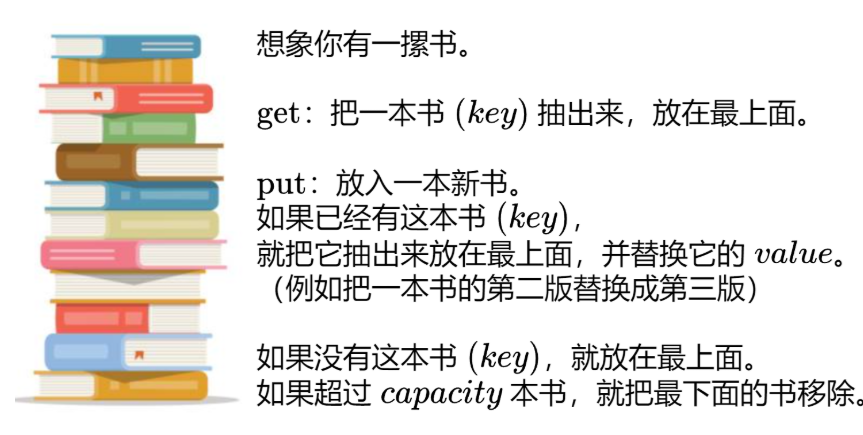  


In [31]:
import collections
class LRUCache:
    def __init__(self,capacity:int):
        self.capacity = capacity
        self.cache = collections.OrderedDict()
    def get(self, key: int) -> int:
        if key not in self.cache:
            return -1
        self.cache.move_to_end(key,last=False)
        return self.cache[key] 
    def put(self, key: int, value: int) -> None:
        self.cache[key] = value
        self.cache.move_to_end(key,last=False)
        if len(self.cache) > self.capacity:
            self.cache.popitem()
        

capacity = 2    
obj = LRUCache(capacity)
param_1 = obj.get('1')
param_1
# obj.put(key,value)

-1

### 72. 编辑距离
> 给你两个单词 word1 和 word2。

### 19. 删除链表的倒数第 N 个结点
> slow, 和 fast,fast 先走n步，然后匀速移动

坑点：会删除头结点，要用哑结点dummy = ListNode(next=head)

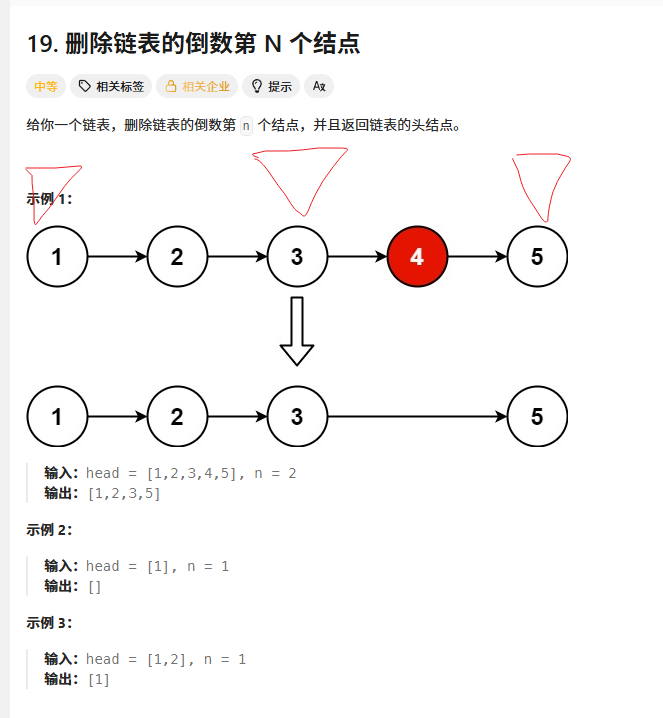

In [60]:
n = 2
while n:
    print(n)
    n-=1

2
1


In [ ]:
def removeNthFromEnd(head,n):
    dummy = ListNode(next = head)
    slow = fast = dummy
    while n:
        fast = fast.next
        n-=1
    while fast and fast.next:
        slow = slow.next
        fast = fast.next
    # delete 操作
    slow.next = slow.next.next
    return dummy.next

### 338. 比特位计数
> 对于给定的整数n, 计算0,1,2,n-1,n 这一共n+1个十进制数中对应的二进制表示中1的个数  

思路：x&(x-1),可以移除x中最后一个1，这也叫做汉明重量，可以统计二进制表示中1的个数，但是明显没有利用数是递增的这一有利条件。  
我发现在二进制表示下，当前数1的个数 = 比当前数的少1的数+1。  
可能有点绕，x =5 ,x&(x-1)=4, 4的1的个数是1, 那5的1的个数就是2, 计算出来的1的个数存在one_nums = [], 里面，这样再求第i个解的时候，可以用到前面已知的解。  
0和1,2的1的数量我们都知道  

In [14]:
def countBits(n):
    dp = [0]*(n+1)
    for i in range(1,n+1):
        dp[i] = dp[i & (i-1)] + 1
        
    return dp

countBits(5)

[0, 1, 1, 2, 1, 2]

### 461. 汉明距离
> 两个整数x,y对应二进制位bin(x)和bin(y)对应位置不相同的数目。
- 思路，^ 后中1的个数：这个和汉明重量很像，n&(n-1),加了一个 ^ 操作

In [12]:
def hammingDistance(x,y):
    cnt, num = 0,x^y
    while num > 0:
        cnt += 1
        num &= (num-1)
    return cnt
hammingDistance(3,1)

1

In [ ]:
# 解题思路1：单调递增栈：利润是栈顶减去栈低
def maxProfit(prices):
    stack = []
    max_profit = 0
    for price in prices:
        while stack and price < stack[-1]:
            max_profit = max(max_profit,stack.pop()-stack[0])
        stack.append(price)
    # 最后一次处理
    return max(max_profit,stack[-1]-stack[0])
        

### 20. 有效的括号
思路：选用栈数据结构，利用一个哈希表决定是否出栈，那最后，栈为空True, 栈不为空为False
- 细节1，可以匹配不上可以提前结束
效果分析：
- 最坏一次遍历就解决了

In [1]:
s = "([])"
def isValid(s):
    stack = []
    hashmap = {')':'(','}':'{',']':'['}
    for c in s:
        if stack and c in hashmap:
            if hashmap[c] == stack[-1]:
                stack.pop()
            else: 
                return False  
        else:
            stack.append(c)
    
    return not stack
isValid(s)
        

True

1. 两数之和
> 找出数组nums中和为target的两个数的下标 O(N)

思路：hashmap = {num,i}, 这里会有一个问题，当相同的num 会更新i, 不过这并不影响计算两数之和。主要利用了哈希表存储之前出现过的数组，那当新的数来的时候，判断存下的数中，有没有diff,有就直接结束，不必遍历完。    
complement：补数/差值, 我用diff 作为变量名字



In [4]:
def twoSum(nums, target):
    hashmap = {}
    for i,num in enumerate(nums):
        print(hashmap)
        diff = target - num
        if diff in hashmap:
            return [hashmap[diff],i]
        hashmap[num] = i
nums = [2,7,11,15]
target = 26
twoSum(nums, target)

{}
{2: 0}
{2: 0, 7: 1}
{2: 0, 7: 1, 11: 2}


[2, 3]

In [ ]:
from typing import List
class Solution:
    def twoSum(self, nums: List[int], target: int) -> List[int]:
        # 相同num,也没关系，会返回两个数最近的一对
        hashmap = {}
        for i, num in enumerate(nums):
            complement = target - num
            if (complement in hashmap):
                return [hashmap[complement],i]
            hashmap[num] = i
        return []   

### 56. 合并区间
> intervals[i] = [starti, endi],合并所有重叠的区间

坑点1：前面的区间会完全包裹住后面的区间，如 [[1,4],[2,3]]，因为没有更新
坑点2：sorted() 会申请一个新内存返回， list.sort()，会在原地修改, 改变内存也没生省下来，可能和列表的长度有关

In [ ]:
def merge(intervals):
    
    intervals.sort(key=lambda x:x[0]) 
    last_start, last_end = intervals[0]

    res = []
    for start,end in intervals[1:]:
        if start > last_end:
            res.append([last_start,last_end])
            last_start = start
        else:
            if last_end > end:
                last_end = last_end
            else:
                last_end = end
    # post 后处理
    res.append([last_start,last_end])    
    print(res)
    
intervals = [[1,3],[2,6],[8,10],[9,18]]
merge(intervals)

[[1, 6], [8, 18]]


### 160. 相交链表
> 找出两个单链表相交的节点

思路：A+C+B = B+C +A
坑点：要清除意识到，如果两个链表没有相交点，按照判断条件p1 != p2，他们最后也会在None相遇，也会正常退出循环


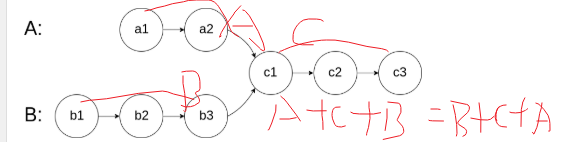  |    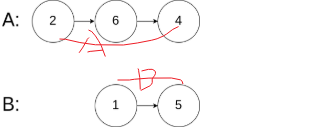

Intersection:相交

In [ ]:
def getIntersectionNode(headA,headB):
    p1,p2 = headA,headB
    while p1 != p2:
        p1 = p1.next if p1 else headB
        p2 = p2.next if p2 else headA
    return p1

### 141. 环形链表
> 给你一个链表的头节点 head ，判断链表中是否有环,则返回 True or False。
### 142. 环形链表 II
> 给定一个链表的头节点  head ，返回链表开始入环的第一个节点。 如果链表无环，则返回 None

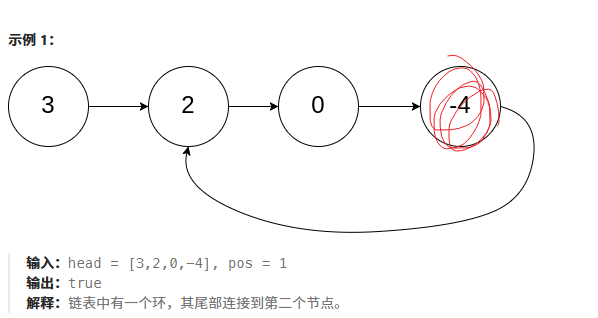  
如上图，首次相遇点一定在环中某个节点，而且是slow第一次入环，fast是第二次入环    
对于问题升级后需要返回相遇节点，这个时候让slow回到头部然后和fast都按照1的速度往前走，即可找到入环点  
这是有证明的，Floyd 判圈算法，1967 年提出的

In [1]:
def hasCycle(head):
    slow , fast  =  head,head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        if slow == fast:
            return True   
    return False

def detectCycle(head):
    slow , fast  =  head,head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        if slow == fast:
            # 开始和上面的hasCycle不一样了
            slow = head
            while slow != fast:
                slow = slow.next
                fast = fast.next
            return slow
    return None
        

### 94. 二叉树的中序遍历
> 给定一个二叉树的根节点 root,返回它的中序遍历。

思路：对于树中每个小数来说，要把他看做整体，其中序遍历的访问顺序严格是：左子树 -> 根节点 -> 右子树。  
一种方案是：dfs: deep first search，的递归版本。  
一种方案是：利用stack 的迭代版本  
两种都要会  
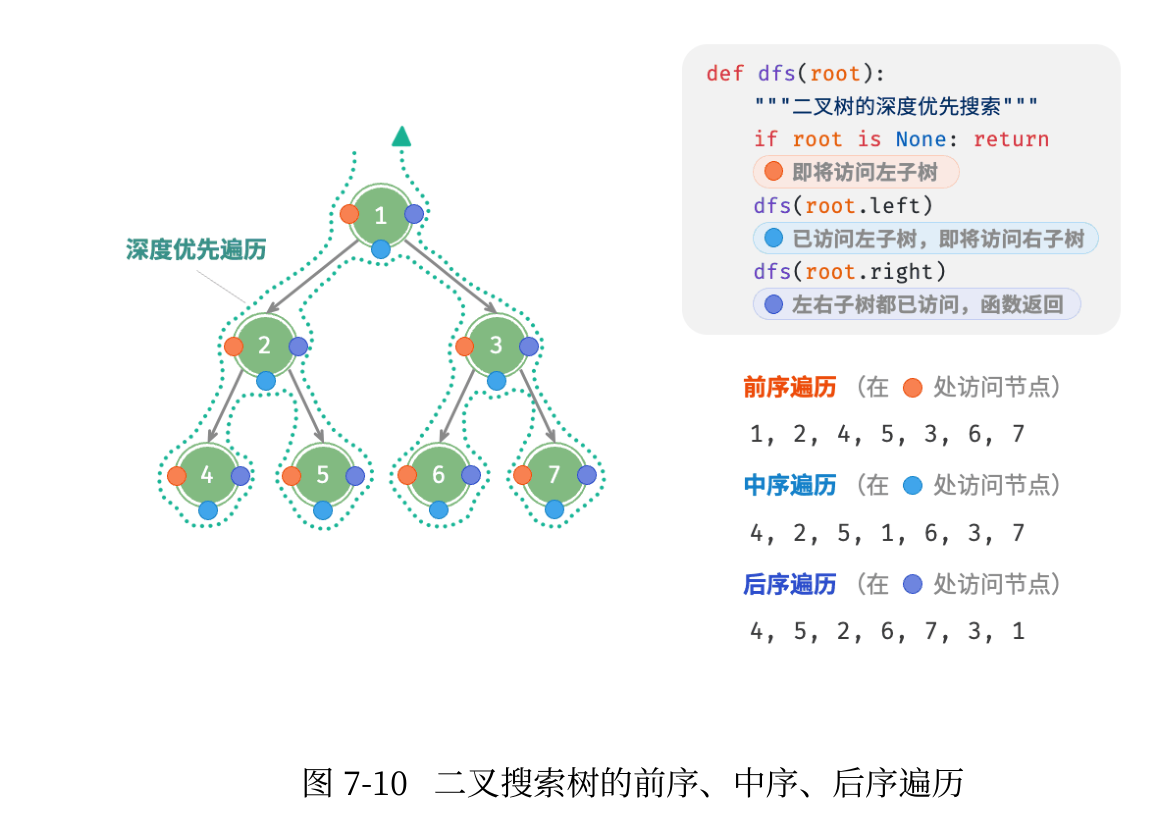  

坑点：利用全局变量，递归的时候那结果存在inorder = []中


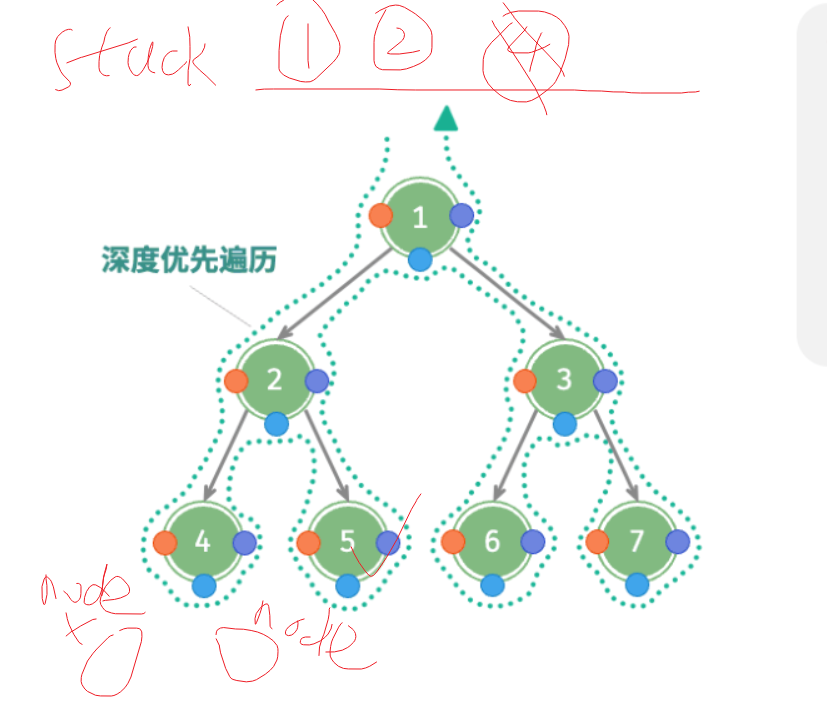  

In [2]:
def inorderTraversal(root):
    inorder = []
    def dfs(root):
        if root:
            return 
        dfs(root.left)
        inorder.append(root.val)
        dfs(root.right)
    dfs(root)
    return inorder

def inorderTraversal(root):
    stack,inorder = [],[]
    node = root
    while node or stack:
        if node:
            stack.append(node)
            node = node.left
        elif stack:
            node = stack.pop()
            inorder.append(node)
            node = node.right
    return inorder

# 感觉两个代码长度差不多
    

### 148. 排序链表
> 给你链表的头结点 head ，请将其按 升序 排列并返回排序后的链表 。

思路： 归并排序，链表版。主要是实现两个函数，一个是findMid(head),一个是mergeList(head1,head2)。在实现一个递归函数mergeSort(head)


In [4]:
def findMid(head):
    # 快慢指针找中点
    slow , fast = head, head.next
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
    return slow
def mergeList(head1,head2):
    # 合并两个有序链表
    tail = dummy = ListNode()
    while list1 is not None and list2 is not None:
        if list1.val < list2.val:
            tail.next = list1
            list1 = list1.next
        else:
            tail.next = list2
            list2 = list2.next
        tail  = tail.next
    tail.next = list2 if list1 is None else list1

    return dummy.next
def sortList(head):
    if not head or not head.next:
        return head
    mid = findMid(head)
    rigth = mid.next
    mid.next = None
    return mergeList(sortList(rigth),sortList(head))


### 234. 回文链表
> 给你一个单链表的头节点 head ，请你判断该链表是否为回文链表。如果是，返回 true ；否则，返回 false。  

思路：绝对不用反转链表，这会破坏原链表结构。所有回文结构的判断都可以用到栈，其实所谓的递归方案也是栈思想。这里先用快慢指针找到链表中点，移动的过程中将节点值入栈。可以写成函数findMid()。通过移动mid和栈pop比较值，这样做的还可以提前结束。 

坑点：slow和fast初始化在head. 这和找中点不一样，哪个是slow和fast初始化在head,head.next. 这两种在链表中有什么区别呢？
- slow=head, fast=head：     mid的位置是 长度n//2 +1
- slow=head, fast=head.next: mid的位置是 奇数：n//2 + 1, 偶数：n//2
> node: 所有的回文结构第一时间都要想要用 栈，后入先出.   
> 只要不想反转链表，一般也可以用栈，比如 正序的两数相加  
> 力扣，2. 两数相加 里面已经把数组逆序存储了，用的是链表结构，这里记好进位就行了，不用栈了  

In [ ]:
def isPalindrome(head) -> bool:
        stack = []
        def findMid(head):
            slow ,fast =  head,head
            while fast and fast.next:
                stack.append(slow.val)
                slow = slow.next
                fast = fast.next.next
            # 后处理
            if fast:
                slow = slow.next
            return slow
        mid = findMid(head)
        
        while mid:
            if mid.val != stack.pop():
                return False
            mid = mid.next
        return True

### 2. 两数相加
> 两个 逆序 的方式存储的链表相加

坑点：按照直觉来做，很容易把代码写的 [分支太多]

carry: 进位,相加产生了进位

python 错误:UnboundLocalError  
未绑定的局部变量错误：在变量尚未赋值之前，就尝试访问它。


In [12]:
x = 98
x // 10, x % 10 

(9, 8)

In [13]:
def addTwoNumbers(l1, l2):
    dummy = ListNode()
    tail = dummy
    carry = 0

    p1, p2 = l1, l2
    while p1 or p2 or carry:
        x = (p1.val if p1 else 0) + (p2.val if p2 else 0) + carry
        carry = x // 10
        tail.next = ListNode(x % 10)
        tail = tail.next

        p1 = p1.next if p1 else None
        p2 = p2.next if p2 else None

    return dummy.next